In [189]:
import numpy as np
import pandas as pd
import re

In [190]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [191]:
df = pd.read_csv('C:\\Users\\ACER\Desktop\\Projects\\Machine Learning Based Real Estate System\\Dataset\\Cleaned_properties_v1.csv')

df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,umang winter hills,sector 77,1.0,7500.0,1333.0,Carpet area: 1340 (124.49 sq.m.),2,2,2,not available,3.0,NaN,0 to 1 Year Old,"['Entertainland Mall', 'Delhi Jaipur Expressway', 'Jhankar Senior Secondary School', 'Singhania University, Manesar', 'Miracles Apollo Hospital', 'Indira Gandhi International Airport', 'Garhi Harsaru Junction', 'Eros Corporate Park', 'Hyatt Regency Gurgaon', 'Aravalli Hills']",NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']"


In [192]:
df.shape

(3856, 17)

`Focus is on ->`

`areaWithType, additionalRoom, agePossession, furnishDetails, features`

### 1. areaWithType

In [193]:
df.sample(5)[['price', 'area', 'areaWithType']]

,price,area,areaWithType
1339,0.28,49123.0,Carpet area: 48811 (4534.69 sq.m.)
469,1.10,1300.0,Super Built up area 1300(120.77 sq.m.)Carpet area: 788 sq.ft. (73.21 sq.m.)
2501,1.45,1650.0,Super Built up area 1650(153.29 sq.m.)
3680,0.32,519.0,Carpet area: 519 (48.22 sq.m.)
2148,0.92,1187.0,Carpet area: 1187 (110.28 sq.m.)


In [194]:
# This function extracts the Super Built up Area

def get_super_built_up_area(text):
    match = re.search('Super Built up area (\d+\.?\d+)', text)
    if match:
        return float(match.group(1))
    return None

In [195]:
# This function extracts the Built up Area or Carpet Area

def get_area(text, area_type):
    match = re.search(area_type +  r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [196]:
# This function checks if the area is provided in sq.m and converts it to sqft if needed

def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    
    match = re.search(r'{} \((\d+\.?\d*) sq.m. \)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639 # Conversion factor from sq.m. to sqft
    return area_value

In [197]:
# Extract Super Built up area and Convert to sqft if Needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Build Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet Area and Convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [198]:
df[['price', 'property_type', 'area', 'areaWithType', 'super_built_up_area', 'built_up_area', 'carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3308,2.37,flat,2061.0,Built Up area: 2060 (191.38 sq.m.)Carpet area: 1600 sq.ft. (148.64 sq.m.),NaN,2060.0,1600.0
928,2.00,flat,2400.0,Super Built up area 2400(222.97 sq.m.),2400.0,NaN,NaN
1942,1.19,flat,1600.0,Carpet area: 1600 (148.64 sq.m.),NaN,NaN,1600.0
29,2.25,flat,2132.0,Super Built up area 2132(198.07 sq.m.),2132.0,NaN,NaN
665,0.74,house,1000.0,Built Up area: 1000 (92.9 sq.m.),NaN,1000.0,NaN


In [199]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price', 'property_type', 'area', 'areaWithType', 'super_built_up_area', 'built_up_area', 'carpet_area']].shape

(536, 7)

In [200]:
df[df['areaWithType'].str.contains('Plot')][['price', 'property_type', 'area', 'areaWithType', 'super_built_up_area', 'built_up_area', 'carpet_area']].shape

(710, 7)

In [201]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 21
facing                 1127
agePossession             1
nearbyLocations         184
furnishDetails         1001
features                661
super_built_up_area    1935
built_up_area          2645
carpet_area            1891
dtype: int64

In [202]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price', 'property_type', 'area', 'areaWithType', 'super_built_up_area', 'built_up_area', 'carpet_area']]

In [203]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
9,0.75,house,600.0,Plot area 600(55.74 sq.m.),NaN,NaN,NaN
12,5.60,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN
15,0.48,house,80.0,Plot area 80(7.43 sq.m.),NaN,NaN,NaN
19,8.50,house,6300.0,Plot area 6300(585.29 sq.m.),NaN,NaN,NaN
23,0.92,house,603.0,Plot area 67(56.02 sq.m.),NaN,NaN,NaN


In [204]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price', 'property_type', 'area', 'areaWithType', 'super_built_up_area', 'built_up_area', 'carpet_area']].index

In [205]:
# Function to Extract Plot Area from 'areaWithType' column

def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [206]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

In [207]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
9,0.75,house,600.0,Plot area 600(55.74 sq.m.),NaN,600.0,NaN
12,5.60,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.0,NaN
15,0.48,house,80.0,Plot area 80(7.43 sq.m.),NaN,80.0,NaN
19,8.50,house,6300.0,Plot area 6300(585.29 sq.m.),NaN,6300.0,NaN
23,0.92,house,603.0,Plot area 67(56.02 sq.m.),NaN,67.0,NaN


In [208]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [209]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale, axis=1)

In [210]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
9,0.75,house,600.0,Plot area 600(55.74 sq.m.),NaN,600.0,NaN
12,5.60,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.0,NaN
15,0.48,house,80.0,Plot area 80(7.43 sq.m.),NaN,80.0,NaN
19,8.50,house,6300.0,Plot area 6300(585.29 sq.m.),NaN,6300.0,NaN
23,0.92,house,603.0,Plot area 67(56.02 sq.m.),NaN,603.0,NaN


In [211]:
# Update original Dataframe

df.update(all_nan_df)

In [212]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 21
facing                 1127
agePossession             1
nearbyLocations         184
furnishDetails         1001
features                661
super_built_up_area    1935
built_up_area          2079
carpet_area            1891
dtype: int64

In [213]:
df.shape

(3856, 20)

### 2. additionalRoom

In [214]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1621
servant room                                      706
study room                                        250
others                                            228
pooja room                                        167
store room                                        103
study room,servant room                           100
pooja room,servant room                            84
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              23
pooja room,others                                  17
pooja room,store room                              16
pooja room,st

In [215]:
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# populate the new columns based on the 'additionalRoom' column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [216]:
df.sample(5)[['additionalRoom', 'study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
186,not available,0,0,0,0,0
1055,servant room,0,1,0,0,0
3089,not available,0,0,0,0,0
2094,study room,1,0,0,0,0
990,"study room,pooja room",1,0,0,1,0


### 3. agePossession

In [217]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1684
5 to 10 Year Old       585
0 to 1 Year Old        536
undefined              343
10+ Year Old           328
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec-23                  20
By 2023                 19
By 2024                 17
Dec-24                  15
Mar-24                  14
Dec-25                   7
Oct-24                   7
Aug-23                   7
Jan-24                   7
Nov-23                   5
Jun-24                   5
Jul-24                   4
Sep-23                   4
Aug-24                   4
By 2025                  4
May-24                   3
Nov-24                   3
Oct-23                   3
Jan-25                   3
Feb-24                   3
Aug-25                   2
Jul-25                   2
Jan-26                   2
Jun 2024                 2
Jun-27                   2
Mar-25                   2
Dec 2023                 2
Jul-27                   2
By 2027       

In [218]:
import re
from datetime import datetime

CURRENT_DATE = datetime.now()  # June 2026 at time of writing

def parse_possession_date(value):
    """Try to parse a possession date string into a datetime object.
    Returns None if it's not a parseable date (e.g. 'undefined', age-range strings)."""
    
    value = value.strip()
    
    # Format: "By 2023", "By 2024", "By 2025", "By 2027"
    match = re.match(r'By (\d{4})', value)
    if match:
        year = int(match.group(1))
        return datetime(year, 12, 31)  # assume end of year
    
    # Format: "Dec-23", "Mar-24", "Jun-27" (Mon-YY)
    match = re.match(r'([A-Za-z]{3})-(\d{2})', value)
    if match:
        month_str, yy = match.group(1), match.group(2)
        try:
            month = datetime.strptime(month_str, '%b').month
            year = 2000 + int(yy)
            return datetime(year, month, 1)
        except ValueError:
            return None
    
    # Format: "Jun 2024", "Dec 2023" (Mon YYYY)
    match = re.match(r'([A-Za-z]{3})\s(\d{4})', value)
    if match:
        month_str, yyyy = match.group(1), match.group(2)
        try:
            month = datetime.strptime(month_str, '%b').month
            year = int(yyyy)
            return datetime(year, month, 1)
        except ValueError:
            return None
    
    return None


def categorize_age_possession(value):
    if pd.isna(value):
        return 'Undefined'
    
    value = str(value).strip()
    
    # --- Existing pre-defined age-range categories ---
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return 'New Property'
    
    if "1 to 5 Year Old" in value:
        return 'Relatively New'
    
    if "5 to 10 Year Old" in value:
        return 'Moderately New'
    
    if "10+ Year Old" in value:
        return 'Old Property'
    
    if value == "undefined" or value == "Undefined":
        return 'Undefined'
    
    # --- Date-based values: "Dec-23", "By 2025", "Jun 2024", "Under Construction" ---
    if value == "Under Construction":
        return 'Under Construction'
    
    possession_date = parse_possession_date(value)
    
    if possession_date is None:
        return 'Undefined'
    
    if possession_date > CURRENT_DATE:
        return 'Under Construction'
    
    # Possession date has passed - calculate actual age now
    age_years = (CURRENT_DATE - possession_date).days / 365.25
    
    if age_years < 1:
        return 'New Property'
    elif age_years < 5:
        return 'Relatively New'
    elif age_years < 10:
        return 'Moderately New'
    else:
        return 'Old Property'


df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [219]:
df['agePossession'].value_counts()

agePossession
Relatively New        1839
New Property           657
Moderately New         585
Undefined              344
Old Property           328
Under Construction     103
Name: count, dtype: int64

### 4. furnishDetails

In [220]:
df.sample(3)[['furnishDetails', 'features']]

,furnishDetails,features
2772,"['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN
746,"['5 Wardrobe', '8 Fan', '1 Exhaust Fan', '5 Geyser', '16 Light', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Recently Renovated', 'Visitor Parking', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"
757,NaN,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"


In [221]:
# Extract all unique furnishings from the furnishDetails column

all_furnishings = []

for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include)) # Get unique Furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing] # Remove empty string

# Create New columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new datafRame with the required columns
furnishings_df = df[['furnishDetails'] +columns_to_include]

In [222]:
furnishings_df.shape

(3856, 19)

In [223]:
furnishings_df.drop(columns=['furnishDetails'], inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_21140\466072287.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'], inplace=True)


In [224]:
furnishings_df.head()

,Curtains,Light,Washing Machine,Fan,Exhaust Fan,Chimney,Wardrobe,Stove,Sofa,AC,Modular Kitchen,Microwave,Water Purifier,TV,Geyser,Fridge,Dining Table,Bed
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,7,0,0,1,1,3,0,0,0,1,0,0,0,3,0,0,0
2,0,20,0,9,1,0,9,0,0,9,1,0,1,9,9,1,0,0
3,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
4,1,10,1,8,1,1,4,1,0,5,1,1,0,0,7,1,0,0


In [225]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [226]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [227]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

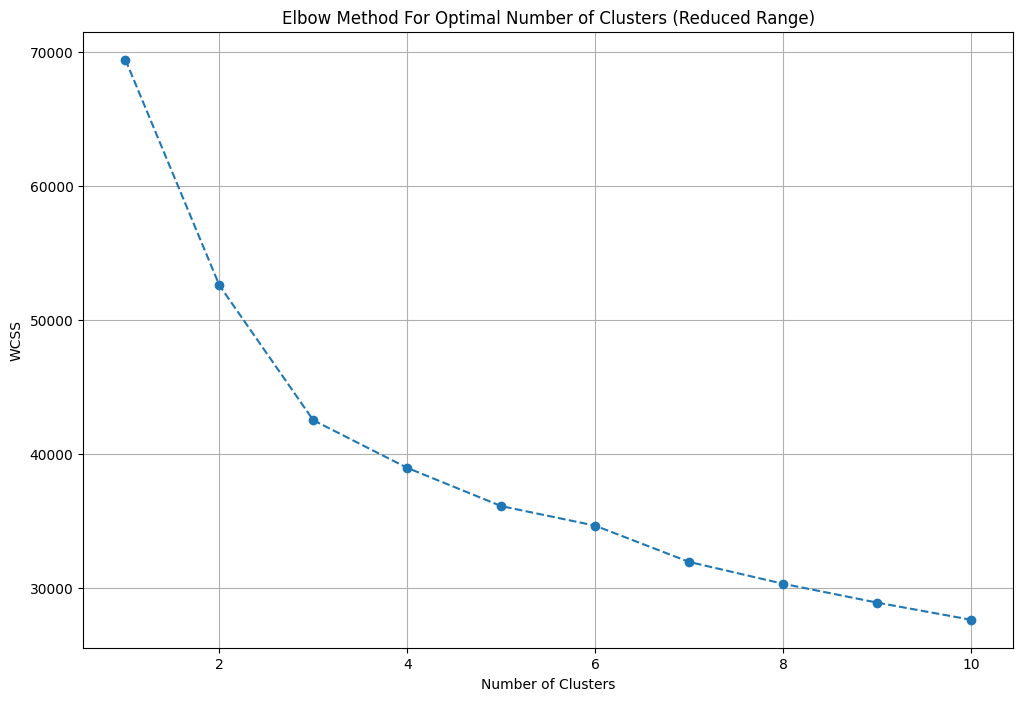

In [228]:
# Plot the Results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [229]:
n_clusters = 3

# Fit the KMeans Model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [230]:
df = df.iloc[:, :-18]

In [231]:
df['furnishing_type'] = cluster_assignments

In [232]:
df.sample(5)[['furnishDetails', 'furnishing_type']]

# 0 -> UnFurnished
# 1 -> SemiFurnished
# 2 -> Furnished

,furnishDetails,furnishing_type
1153,"['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",1
165,"['5 Geyser', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",1
2678,[],1
3493,"['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",1
2405,"['3 Wardrobe', '6 Fan', '1 Exhaust Fan', '1 Geyser', '7 Light', '5 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0


### 5. features

In [233]:
df[['society', 'features']].sample(5)

,society,features
102,smart world gems,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Club house / Community Center']"
3154,emaar the palm springs,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Fitness Centre / GYM', 'Club house / Community Center']"
3343,emaar mgf emerald floors premier,"['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Club house / Community Center']"
941,vatika gurgaon,"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'Maintenance Staff', 'Park', 'Visitor Parking']"
189,emaar mgf emerald floors premier,"['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Spacious Interiors', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Water softening plant']"


In [234]:
df['features'].isnull().sum()

661

In [235]:
import pandas as pd
app_df = pd.read_csv('C:\\Users\\ACER\\Desktop\\Projects\\Machine Learning Based Real Estate System\\Dataset\\appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [236]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [237]:
temp_df = df[df['features'].isnull()]

In [238]:
temp_df.shape

(661, 26)

In [239]:
x = temp_df.merge(app_df, left_on='society', right_on='PropertyName', how='left')['TopFacilities']

In [240]:
df.loc[temp_df.index, 'features'] = x.values

In [241]:
df['features'].isnull().sum()

507

In [242]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [243]:
# Convert the string representation of Lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a Binary Matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the Binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [244]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
290,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3462,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0
3247,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1104,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,0,0,0
2106,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0


In [245]:
features_binary_df.shape

(3856, 130)

In [246]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

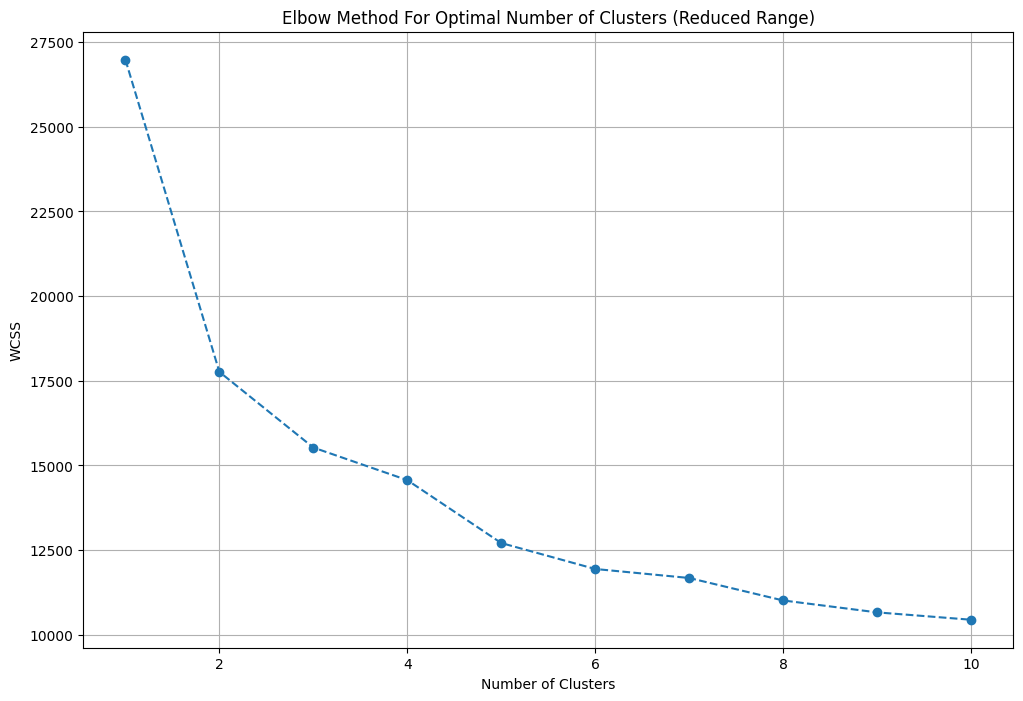

In [247]:
# Plot the Results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [248]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}

# Calculate Luxury Score for Each Row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [249]:
df['luxury_score'] = luxury_score

In [250]:
df.sample(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
1474,flat,m3m latitude,sector 65,4.7,19747.0,2380.0,Super Built up area 2380(221.11 sq.m.)Carpet area: 1231 sq.ft. (114.36 sq.m.),3,3,3+,"pooja room,servant room",9.0,North-East,Relatively New,"['Sector 55-56 Metro Station', 'M3M Cosmopolitan', 'Badshahpur Sohna Rd Hwy, Haryana', 'NH 48, Sector 78', ""St. Xavier's High School"", 'Gurugram University', 'Medanta -The Medicity', 'M3M International Financial Center (IFC)', 'Holiday Inn Express Gurugram Sec 50']","['4 Fan', '1 Exhaust Fan', '4 Geyser', '9 Light', '5 AC', '1 Chimney', '1 Modular Kitchen', '4 Wardrobe', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",2380.0,NaN,1231.0,0,1,0,1,0,0,"[Security / Fire Alarm, Intercom Facility, Lift(s), Maintenance Staff, Water Storage, Park, Visitor Parking]",44


In [251]:
# Columns to Drop ->

df.drop(columns=['nearbyLocations', 'furnishDetails', 'features', 'features_list', 'additionalRoom'], inplace=True)

In [252]:
df.shape

(3856, 23)

In [253]:
df.to_csv('C:\\Users\\ACER\\Desktop\\Projects\\Machine Learning Based Real Estate System\\Dataset\\Cleaned_Properties_V2.csv', index=False)